In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker 
from scipy.special import erf
import os

In [2]:
def plot_data(x, y, title, filename, color='k', additional_plot=None, fill_between=None, dashed_plot=None, xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=(4, 2.2))
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    
    ax.set_xlabel('time', fontsize=15)
    ax.tick_params(axis='x', labelbottom=False)
    ax.yaxis.set_visible(False)
    [ax.spines[spine].set_visible(False) for spine in ['top', 'right', 'left']]
    ax.plot(x, y, color=color)
    
    if additional_plot:
        ax.plot(*additional_plot)
    if fill_between:
        ax.fill_between(*fill_between, alpha=0.4)
    if dashed_plot:
        ax.plot(*dashed_plot, linestyle='--', color='k')
   
    ax.set_title(title, fontsize=20)
    plt.tight_layout()
    fig.savefig('graphs/' + filename, dpi=500)

In [3]:
results_prob = os.path.join(os.getcwd(), "results_prob")
sorted(os.listdir(results_prob))

['Brownian_128_128_S_Mamba_custom_M_ft128_sl48_ll128_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'Brownian_Linear_128_128_S_Mamba_custom_M_ft128_sl48_ll128_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'ECL_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'ECL_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'Sines_se_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'Sines_se_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'Traffic_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'Traffic_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'VDP_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_

In [4]:
# Load data
results_prob = os.path.join(os.getcwd(), "results_prob")
folders = ['results_prob/'+f for f in sorted(os.listdir(results_prob)) if os.path.isdir(os.path.join(results_prob, f))]

folder = folders[3] + '/'
data_files = ['input.npy', 'trues.npy', 'det_pred.npy', 'pred.npy', 'sigs.npy']
ps, gt, pr, mu, sg = (np.load(folder + file) for file in data_files)

i = 0
past = ps[i, :, -1]
t_past = np.arange(past.size)

future = gt[i, :48, -1]
t_future = past.size + np.arange(future.size)

pred = pr[i, :48, -1]
pred_mean = mu[i, :48, -1]
pred_sigma = sg[i, :48, -1]


# Ensure continuity in future predictions
future = np.concatenate(([past[-1]],future))
pred = np.concatenate(([past[-1]], pred))
pred_mean = np.concatenate(([past[-1]], pred_mean))
pred_sigma = np.concatenate(([0], pred_sigma))
t_future = np.concatenate(([t_past[-1]], t_future))

# Calculate consistent x-limits and y-limits across all plots
x_max = past.size + future.size
y_min = min(past.min(), future.min(),  (pred_mean - pred_sigma).min())
y_max = max(past.max(), future.max(),  (pred_mean + pred_sigma).max())
xlim = (0, x_max)
ylim = (y_min, y_max)

folder

'results_prob/ECL_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0/'

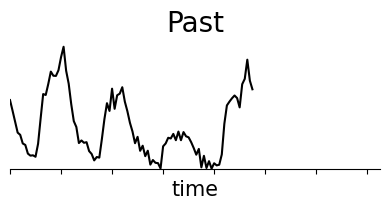

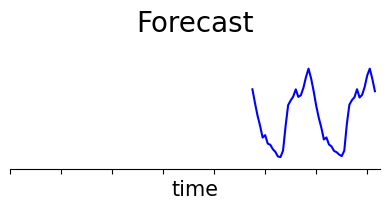

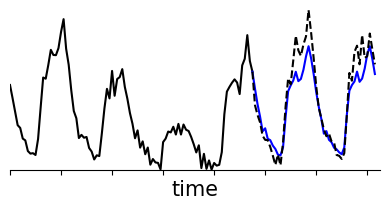

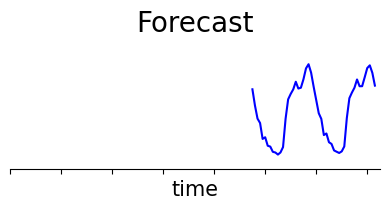

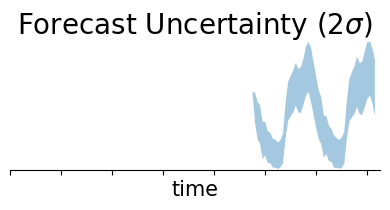

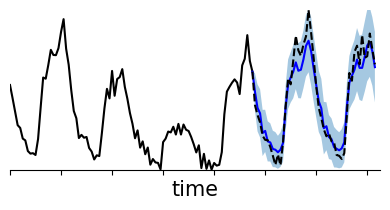

In [5]:
# Plot Past
plot_data(t_past, past, 'Past', 'fig1_past.png', xlim=xlim, ylim=ylim)

# Plot Deterministic
plot_data(t_future, pred, 'Forecast', 'fig1_pred.png', color='blue', xlim=xlim, ylim=ylim)

# Plot Full
plot_data(t_past, past, '', 'fig1_determ.png', color='k', additional_plot=(t_future, pred, 'blue'), dashed_plot=(t_future, future), xlim=xlim, ylim=ylim)

# Plot Future Mean
plot_data(t_future, pred_mean, 'Forecast', 'fig1_future_mean.png', color='blue', xlim=xlim, ylim=ylim)

# Plot Future Uncertainty
plot_data(t_past, past, 'Forecast Uncertainty'+r' ($2\sigma$)', 'fig1_future_uncertainty.png', color='white',
          fill_between=(t_future, pred_mean - 2*pred_sigma, pred_mean + 2*pred_sigma), xlim=xlim, ylim=ylim)

# Plot Prediction with Uncertainty
plot_data(t_past, past, '', 'fig1_uncertainty.png', color='k',
          additional_plot=(t_future, pred_mean, 'blue'),
          fill_between=(t_future, pred_mean - 2*pred_sigma, pred_mean + 2*pred_sigma),
          dashed_plot=(t_future, future), xlim=xlim, ylim=ylim)


In [6]:
bins = np.concatenate((-100*np.ones(1),np.linspace(-10,10,250),100*np.ones(1)))
zz = (bins[:-1]+bins[1:])/2
dz = (zz[20]-zz[19]) 

def z_comparison(zr,ax=None):
    zr = zr.reshape(-1)
    h = np.histogram(zr,density=True,bins=bins)
    dens_p=h[0]
    
    lpz = (-zz*zz/2) - np.log(2*np.pi)/2

    inds = dens_p>0
    inds[[0, -1]] = False
    kl = dz*((dens_p[inds]*(np.log(dens_p[inds])-lpz[inds]))).sum()


    var = zr.var()

    if ax:
        cts = ax.hist(zr,density=True,bins=bins)
        pz = np.exp(lpz)
        ax.plot(zz,pz)
        ax.set_xlim(-4,4)
        
    return kl,var


In [7]:
def make_figure(ps, gt, pr, mu, sg,brownian=False,corner=None,unit=''):
    z = (gt-mu)/sg

    if brownian:
        fig, ax = plt.subplot_mosaic([['ex1', 'ex1', 'ex2','ex2'],
                                      ['result1','result1','result2','result2'],
                                      ['zone', 'zmid', 'zend','zall'],
                                      ['kl', 'kl', 'zvar','zvar']], figsize=(12, 5*(4/3)))
        
    else:
        fig, ax = plt.subplot_mosaic([['ex1', 'ex1', 'ex2','ex2'],
                                      ['zone', 'zmid', 'zend','zall'],
                                      ['kl', 'kl', 'zvar','zvar']], figsize=(9,5))
        

    first = True  # Flag to ensure label appears only once
    handles, labels = [], []  # Store handles and labels for a single legend
    
    for (i, axi) in zip((1, ps.shape[0]//2), (ax['ex1'], ax['ex2'])):
        past = ps[i, :, -1]
        t_past = np.arange(past.size)

        future = gt[i, :, -1]
        t_future = past.size + np.arange(future.size)

        pred_mean = mu[i, :, -1]
        pred_sigma = sg[i, :, -1]

        future = np.concatenate(([past[-1]], future))
        pred_mean = np.concatenate(([past[-1]], pred_mean))
        pred_sigma = np.concatenate(([0], pred_sigma))
        t_future = np.concatenate(([t_past[-1]], t_future))

        # Use label only for the first plot
        label_forecast = 'Forecast' if first else None
        label_uncertainty_1 = r'Forecast Uncertainty ($1\sigma$)' if first else None
        label_uncertainty_2 = r'Forecast Uncertainty ($2\sigma$)' if first else None
        label_gt = 'Ground Truth' if first else None

        axi.plot(t_past, past, color='k')


        line_forecast, = axi.plot(t_future, pred_mean, label=label_forecast)
        fill_1 = axi.fill_between(t_future, pred_mean - pred_sigma, pred_mean + pred_sigma,
                                  alpha=.4, color='blue', label=label_uncertainty_1)
        fill_2 = axi.fill_between(t_future, pred_mean - 2*pred_sigma, pred_mean - pred_sigma,
                                  alpha=.2, color='blue', label=label_uncertainty_2)
        fill_2 = axi.fill_between(t_future, pred_mean + 2*pred_sigma, pred_mean + pred_sigma,
                                  alpha=.2, color='blue', label=label_uncertainty_2)

        line_gt, = axi.plot(t_future, future, linestyle='--', color='k',label=label_gt)

        if first:
            handles.extend([line_gt,line_forecast, fill_1, fill_2])
            labels.extend([label_gt,label_forecast, label_uncertainty_1, label_uncertainty_2])

        axi.set_xlabel('time '+unit)
        axi.set_xlim((t_past[0], t_future[-1]))

        first = False  # Ensure labels are only added once

    if brownian:
        first_brownian = True
        for (i, axup, axi) in zip((1, ps.shape[0]//2), (ax['ex1'], ax['ex2']), (ax['result1'], ax['result2'])):
            past = ps[i, :, -1]
            t_past = np.arange(past.size)

            future = gt[i, :, -1]
            t_future = past.size + np.arange(future.size)

            # Use label only for the first plot
            label_brmean = 'Brownian mean' if first_brownian else None
            label_br1sigma = r'Brownian uncertainty ($1\sigma$)' if first_brownian else None
            label_br2sigma = r'Brownian uncertainty ($2\sigma$)' if first_brownian else None

            br_mean = np.concatenate(([past[-1]], past[-1]*np.ones(future.size)))
            br_sigma = np.sqrt(np.arange(1+future.size)) 
            
            future = np.concatenate(([past[-1]], future))
            t_future = np.concatenate(([t_past[-1]], t_future))        

            axi.plot(t_past, past, color='k')
            line_gt, = axi.plot(t_future, future, linestyle='--', color='k',label=label_gt)
            line_brmean, = axi.plot(t_future, br_mean,color='green',label=label_brmean)
            fill_br1sigma = axi.fill_between(t_future, br_mean - br_sigma, br_mean + br_sigma,
                                             alpha=.4, color='green',label=label_br1sigma)
            fill_br2sigma = axi.fill_between(t_future, br_mean + br_sigma, br_mean + 2*br_sigma,
                                             alpha=.2, color='green',label=label_br2sigma)
            fill_br2sigma = axi.fill_between(t_future, br_mean - 2*br_sigma, br_mean - br_sigma,
                                             alpha=.2, color='green')
            axi.set_ylim(axup.get_ylim())

            axi.set_xlabel('time')
            axi.set_xlim((t_past[0], t_future[-1]))

            first_brownian = False


    for i, axi in zip((0, (z.shape[1])//2-1, z.shape[1]-1), [ax['zone'], ax['zmid'], ax['zend']]):
        zr = z[:, i, :]
        k, v = z_comparison(zr, axi)
        axi.set_xlabel(r'$z_\tau^n$ at step $\tau=${}'.format(i+1)+unit)

    ax['zall'].set_xlabel(r'$z_\tau^n$ for all $\tau$')
    k, v = z_comparison(z, ax['zall'])

    tau = np.arange(z.shape[1]) if z.shape[1] <= 128 else np.linspace(0, z.shape[1]-1, 100).astype(int)
    kl, var = [], []
    for i, t in enumerate(tau):
        zr = z[:, t, :]
        k, v = z_comparison(zr)
        kl.append(1.0 * k)
        var.append(1.0 * v)

    ax['kl'].plot(tau, kl)
    ax['kl'].set_ylabel('KL')
    ax['kl'].set_xlabel(r'$\tau$'+unit,fontsize=12)
    ax['kl'].axhline(0.,linestyle='dashed',color='gray')
    ax['kl'].set_xlim(0,tau[-1])

    ax['zvar'].plot(tau, var)
    ax['zvar'].set_ylabel(r'$z_\tau$ variance')
    ax['zvar'].set_xlabel(r'$\tau$ '+unit,fontsize=12)
    ax['zvar'].axhline(1.,linestyle='dashed',color='gray')
    ax['zvar'].set_xlim(0,tau[-1])

    # Set scientific notation
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)

    for key in ax.keys():
        ax[key].ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

    # Add legend outside the figure
    if brownian:
        fig.legend(handles, labels, loc='upper center', ncol=7, bbox_to_anchor=(0.5, .99), frameon=False)
        fig.text(0.03, 0.99, corner, fontsize=18, fontweight='bold', ha='left', va='top')
    else:
        fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, .97), frameon=False)
        fig.text(0.03, 0.97, corner, fontsize=18, fontweight='bold', ha='left', va='top')

    return fig


In [8]:
inds = [5,9,3,7,4,8,2,6,0,1]

folders = ['results_prob/'+f for f in [sorted(os.listdir(results_prob))[i] for i in inds]]
folders

['results_prob/Sines_se_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'results_prob/VDP_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'results_prob/ECL_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'results_prob/Traffic_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'results_prob/Sines_se_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'results_prob/VDP_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'results_prob/ECL_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0',
 'results_prob/Traffic_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_p

In [9]:

titles = ['Sines example','Van der Pol example','Electricity example','Traffic example',
          'Sines example with S-Mamba for uncertainty','Van der Pol example with S-Mamba for uncertainty',
          'Electricity example with S-Mamba for uncertainty','Traffic example with S-Mamba for uncertainty']
#,          'Brownian with S-Mamba for uncertainty','Brownian  with fully connected NN for uncertainty',]

results_prob/Sines_se_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0


results_prob/VDP_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0
results_prob/ECL_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0
results_prob/Traffic_Linear_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0
results_prob/Sines_se_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0
results_prob/VDP_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0
results_prob/ECL_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0
results_prob/Traffic_96_96_S_Mamba_custom_M_ft96_sl48_ll96_pl512_dm8_nh3_el1_dl512_df1_fctimeF_ebTrue_dtExp_projection_0


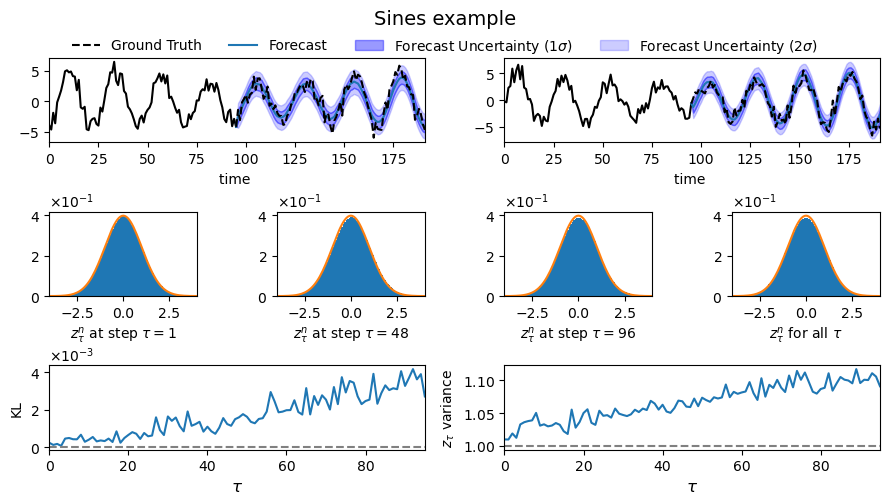

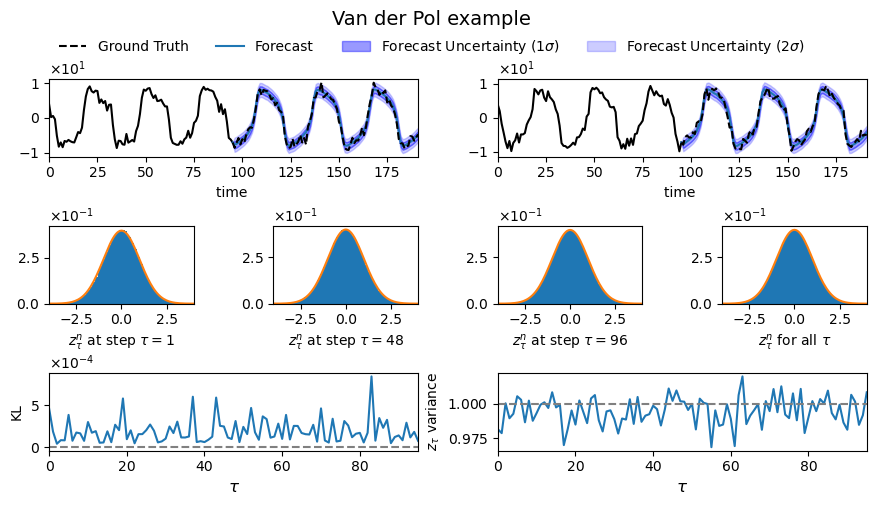

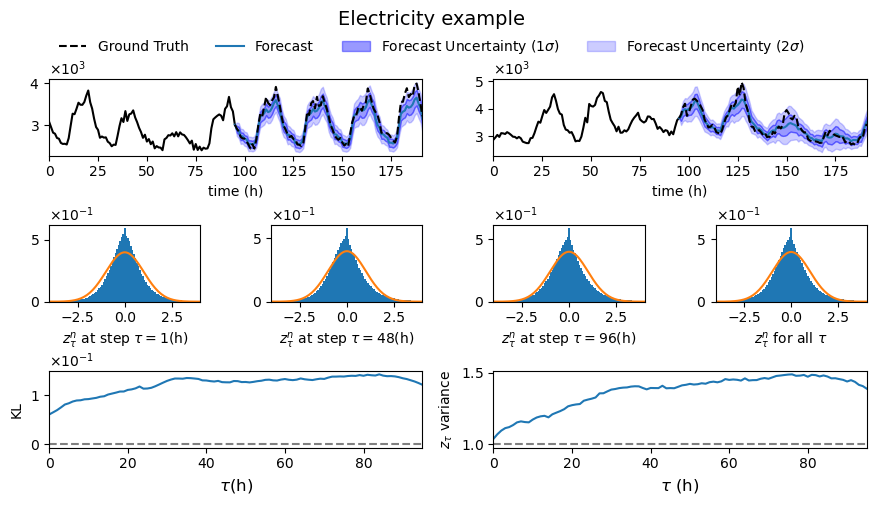

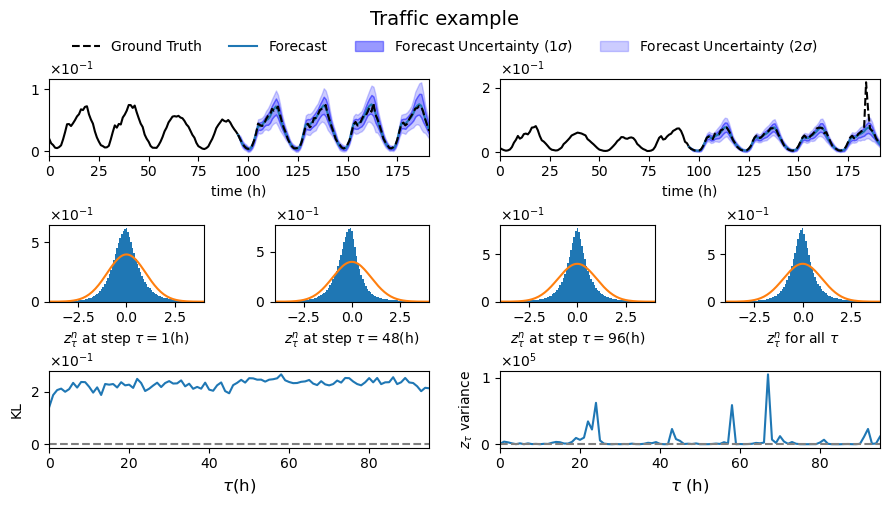

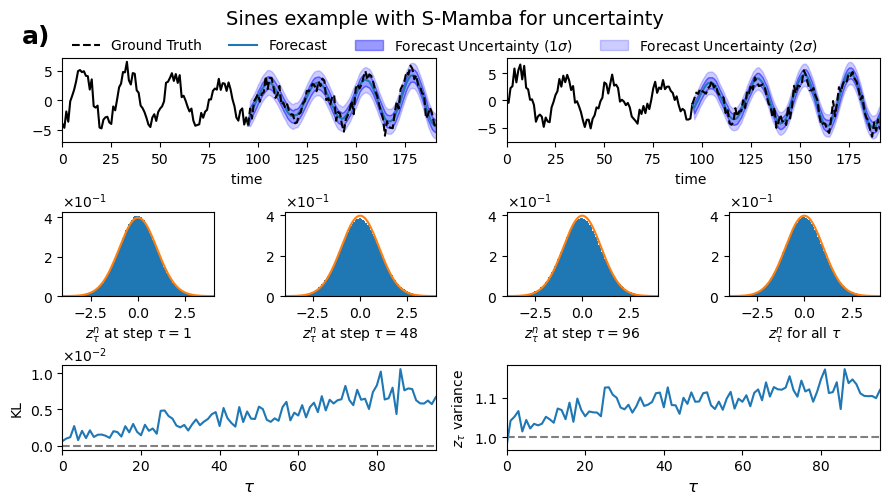

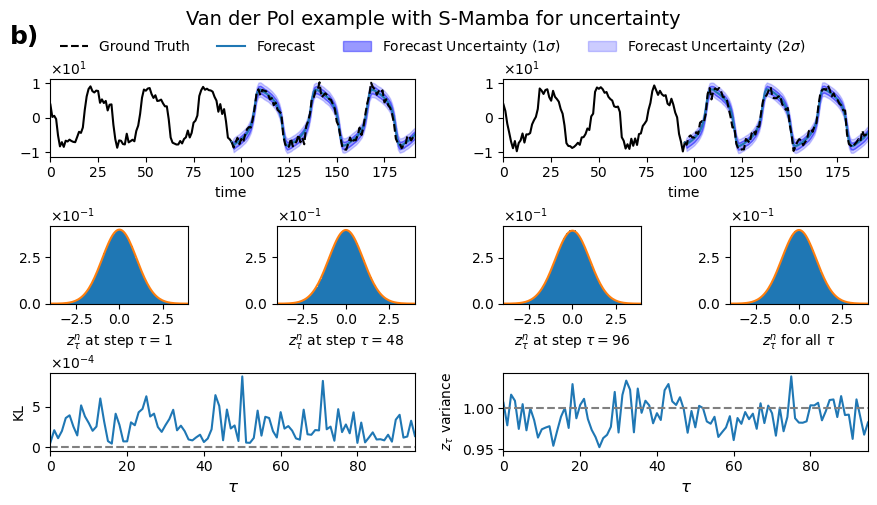

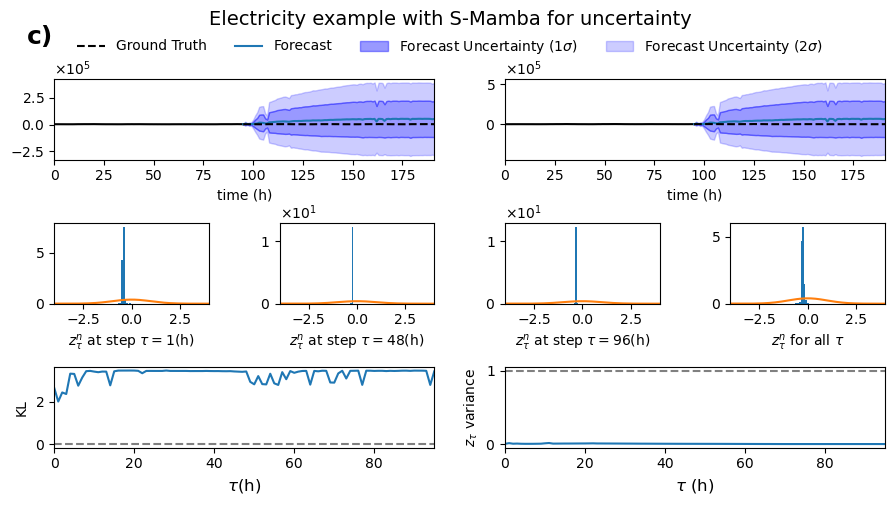

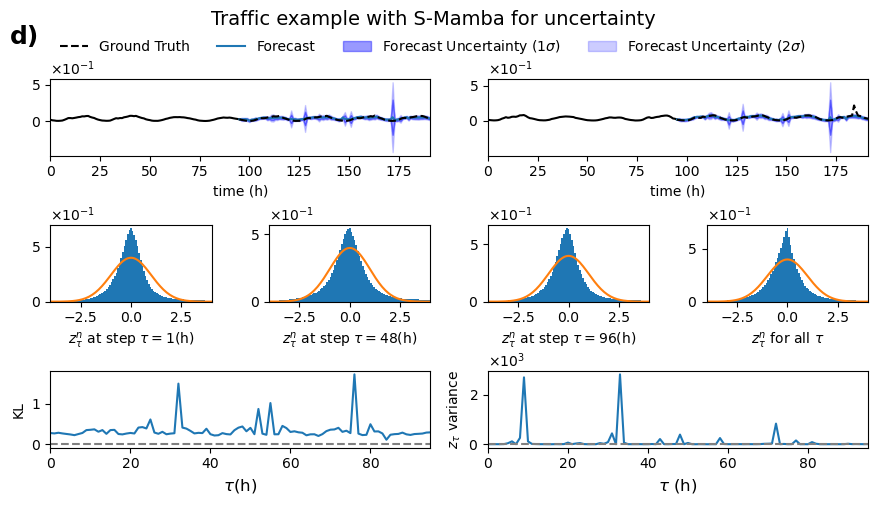

In [10]:


lb = ['','','','','a)','b)','c)','d)']
for i in range( min(len(folders),len(titles))):
    folder,title,label = folders[i],titles[i],lb[i%len(lb)]
    print(folder)
    folder +='/'

    data_files = ['input.npy', 'trues.npy', 'det_pred.npy', 'pred.npy', 'sigs.npy']
    ps, gt, pr, mu, sg = (np.load(folder + file) for file in data_files)

    fig = make_figure(ps, gt, pr, mu, sg,brownian=('Brownian'in title),corner=label,unit=('(h)' if (('Elec' in title) or ('Traffic' in title)) else ''))
    fig.suptitle(title,fontsize=14,y=1.0)
    plt.tight_layout(h_pad=.01)
    plt.savefig('graphs/'+title.replace(" ", "_").replace("-", "_")+'.png',dpi=900)

In [11]:
# #electricity
# folder =folders[2]
# title = titles[2]


# data_files = ['input.npy', 'trues.npy', 'det_pred.npy', 'pred.npy', 'sigs.npy']
# ps, gt, pr, mu, sg = (np.load(folder +'/'+ file) for file in data_files)
# z = (mu-gt)/sg


In [12]:

def plot_real_error(folder, title):

    data_files = ['input.npy', 'trues.npy', 'det_pred.npy', 'pred.npy', 'sigs.npy']
    ps, gt, pr, mu, sg = (np.load(f"{folder}/{file}") for file in data_files)
    z = (mu - gt) / sg
    
    print('gt mean:', gt.mean())
    print('det mean:', np.abs(pr - gt).mean(), 'prob mean:', np.abs(mu - gt).mean())
    [print('{}sigma - {}'.format(i+1,((np.abs(z))<(i+1)).mean())) for i in range(3)]
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 2.5))
    
    ax[0].plot(np.abs(pr - gt).mean(axis=-1).mean(axis=0), label='Deterministic')
    ax[0].plot(np.abs(mu - gt).mean(axis=-1).mean(axis=0), label='Probabilistic')
    ax[0].axhline(np.abs(pr - gt).mean(), label='Average (deterministic)', linestyle='dashed')
    ax[0].axhline(np.abs(mu - gt).mean(), label='Average (probabilistic)', linestyle='dashed', color='orange')
    ax[0].legend(ncol=2)
    
    targets = [0.683, 0.954, 0.997]
    colors = ['r', 'orange', 'b']
    
    for i in range(3):
        ax[1].plot(((np.abs(z)) < (i + 1)).mean(axis=-1).mean(axis=0), label=r'{}$\sigma$'.format(i + 1), color=colors[i])
        ax[1].axhline(targets[i], color=colors[i], linestyle='dashed')
    
    ax[1].legend(ncol=3)
    
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    
    for axi in ax:
        axi.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
        axi.set_xlim(0, 96)
        axi.set_xlabel(r'$\tau$ (h)', fontsize=12)
    
    ax[0].set_ylabel('MAE ')
    ax[1].set_ylabel('Fraction within interval')
    ax[1].set_ylim(0.45, 1)
    
    plt.tight_layout()
    fig.suptitle(title,fontsize=14,y=1.0)
    
    # Generate file name based on title
    file_name = f"graphs/{title.split()[0].lower()}_err.png"
    plt.savefig(file_name, dpi=600)
    print(f"Plot saved as {file_name}")

gt mean: 2659.857975038855
det mean: 213.46723134730584 prob mean: 209.03677812579573
1sigma - 0.7287232013341657
2sigma - 0.9322012728455265
3sigma - 0.9775160299423289
Plot saved as graphs/electricity_err.png


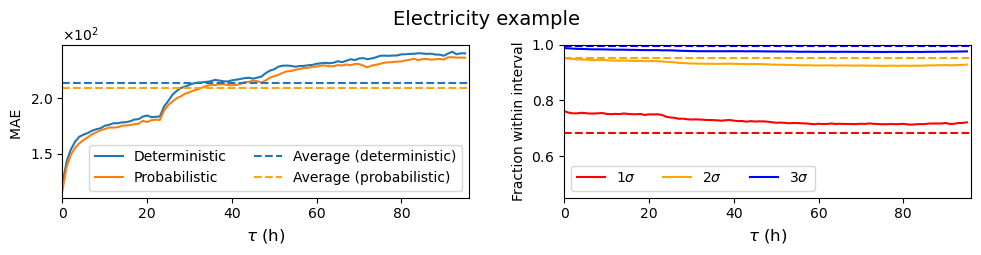

In [13]:
folder =folders[2]
title = titles[2]
plot_real_error(folder,title)

gt mean: 0.05866366150932502
det mean: 0.011714794461932907 prob mean: 0.012111515248287094
1sigma - 0.8379311067856422
2sigma - 0.9565383279299906
3sigma - 0.9810258041905194
Plot saved as graphs/traffic_err.png


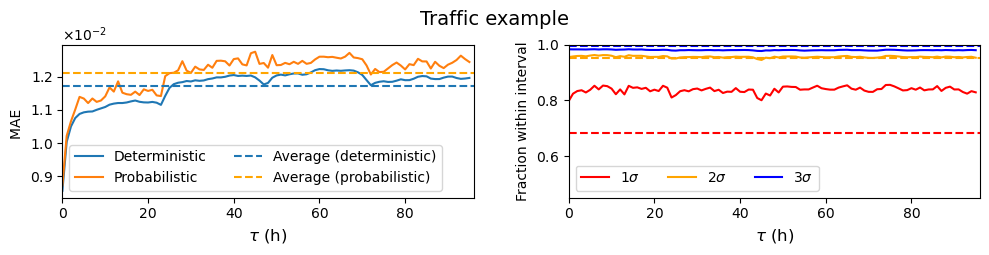

In [14]:
folder =folders[3]
title = titles[3]
plot_real_error(folder,title)